## Calculate the Interaction Energy between the simulated ligands and their surroundings

### Code Base

#### Imports

In [1]:
import os, sys, glob
from datetime import datetime
#import jax.numpy as jnp
import mdtraj as md
from openmm import *
from openmm.app import *
from openmm.unit import *

#### Function Definitions

In [2]:
#Other Functions using both openmm and jax
def obtain_system_subset(old_system_fn:str, old_pdb_fn:str, new_system_fn:str, new_pdb_fn:str, old_selection:str):
    """
    WARNING: This function is constructed under the assumption that new_pdb_fn is a pdb file that is
    already reduced to the selection of the system that you would like

    I.E. It is assumed that selection (old_selection) on the pdb file associated with the old system (old_pdb_fn, old_system_fn)
    was already used to write the pdb file from which new indices are retrieved (new_pdb_fn)

    Parameters:
        old_system_fn: string: the xml file from which the system to be 'sliced' will be loaded
        old_pdb_fn: string: pdb file associated with the old_system_fn xml file
            Note: (old_pdb_fn, old_system_fn) are likely a pdb xml pair used to run previous simulation
        new_system_fn: string: the filename to write the newly constructed 'sliced' system
        new_pdb_fn: string: filename pointing to a pdb which already contains the atoms to be sliced from old_system
            Note: new_pdb_fn should have been generated by making old_selection against old_pdb_fn and saving the selection to pdb
        old_selection: string: a selection string associated with the portion of old_system and old_pdb that you would like expressed in a new system

    Returns:
        None - the newly built system is written to new_system_fn    
    """
    #Load PDBs
    print('Load Files')
    old_pdb = md.load(old_pdb_fn)
    new_pdb = md.load(new_pdb_fn)
    #Map old indices to new indices
    assert old_pdb.top.select(old_selection).shape == new_pdb.top.select('all').shape
    index_map = jnp.array((old_pdb.top.select(old_selection), new_pdb.top.select('all'))).T
    assert jnp.all(index_map[:, 1] == jnp.arange(index_map.shape[0]))
    
    with open(old_system_fn, 'r') as f:
        old_system = XmlSerializer.deserialize(f.read())
    
    #Get Forces from old system
    print('Read Forces')
    hbf = old_system.getForce([type(force) == HarmonicBondForce for force in old_system.getForces()].index(True))
    haf = old_system.getForce([type(force) == HarmonicAngleForce for force in old_system.getForces()].index(True))
    ptf = old_system.getForce([type(force) == PeriodicTorsionForce for force in old_system.getForces()].index(True))
    nbf = old_system.getForce([type(force) == NonbondedForce for force in old_system.getForces()].index(True))

    #Get Nonbonded parameters for all particles from old system
    print('Obtain Charges, Sigmas, Epsilons')
    if nbf.getNumParticleParameterOffsets() != 0:
        raise NotImplementedError
    charges = jnp.zeros(nbf.getNumParticles())
    sigmas = jnp.zeros(nbf.getNumParticles())
    epsilons = jnp.zeros(nbf.getNumParticles())
    for i in range(nbf.getNumParticles()):
        charges = charges.at[i].set(nbf.getParticleParameters(i)[0]._value)
        sigmas = sigmas.at[i].set(nbf.getParticleParameters(i)[1]._value)
        epsilons = epsilons.at[i].set(nbf.getParticleParameters(i)[2]._value)

    #Build the New System from scratch
    print('Building New System')
    build = System()
    #Add Particles
    #iterate over the list of new indices, retrieve the previous index and the mass of that particle
    for i in range(index_map.shape[0]):
        build.addParticle(old_system.getParticleMass(index_map[:, 0][jnp.where(index_map[:, 1] == i)].item()))
    
    #Add Constraints
    print('Adding New Constraints')
    for i in range(old_system.getNumConstraints()):
        params = old_system.getConstraintParameters(i)
        if jnp.any(index_map[:, 0] == params[0]) and jnp.any(index_map[:, 0] == params[1]):
            params[0] = index_map[:, 1][jnp.where(index_map[:, 0] == params[0])].item()
            params[1] = index_map[:, 1][jnp.where(index_map[:, 0] == params[1])].item()
            build.addConstraint(*params)

    #Build new Harmonic Bond Force and replace the old indices with the new ones based on the map
    print('Adding New HarmonicBondForce')
    new_hbf = HarmonicBondForce()
    for i in range(hbf.getNumBonds()):
        params = hbf.getBondParameters(i)
        if jnp.any(index_map[:, 0] == params[0]) and jnp.any(index_map[:, 0] == params[1]):
            params[0] = index_map[:, 1][jnp.where(index_map[:, 0] == params[0])].item()
            params[1] = index_map[:, 1][jnp.where(index_map[:, 0] == params[1])].item()
            new_hbf.addBond(*params)
    build.addForce(new_hbf)

    #Build new Harmonic Angle Force
    print('Adding New HarmonicAngleForce') 
    new_haf = HarmonicAngleForce()
    for i in range(haf.getNumAngles()):
        params = haf.getAngleParameters(i)
        if jnp.any(index_map[:, 0] == params[0]) and jnp.any(index_map[:, 0] == params[1]) and jnp.any(index_map[:, 0] == params[2]):
            params[0] = index_map[:, 1][jnp.where(index_map[:, 0] == params[0])].item()
            params[1] = index_map[:, 1][jnp.where(index_map[:, 0] == params[1])].item()
            params[2] = index_map[:, 1][jnp.where(index_map[:, 0] == params[2])].item()
            new_haf.addAngle(*params)
    build.addForce(new_haf)

    #Build new Periodic Torsion Force
    print('Adding New PeriodicTorsionForce') 
    new_ptf = PeriodicTorsionForce()
    for i in range(ptf.getNumTorsions()):
        params = ptf.getTorsionParameters(i)
        if jnp.any(index_map[:, 0] == params[0]) and jnp.any(index_map[:, 0] == params[1]) and jnp.any(index_map[:, 0] == params[2]) and jnp.any(index_map[:, 0] == params[3]):
            params[0] = index_map[:, 1][jnp.where(index_map[:, 0] == params[0])].item()
            params[1] = index_map[:, 1][jnp.where(index_map[:, 0] == params[1])].item()
            params[2] = index_map[:, 1][jnp.where(index_map[:, 0] == params[2])].item()
            params[3] = index_map[:, 1][jnp.where(index_map[:, 0] == params[3])].item()
            new_ptf.addTorsion(*params)
    build.addForce(new_ptf)

    #Build new Nonbonded Force
    print('Adding New NonBondedForce') 
    new_charges = charges[index_map[:, 0]]
    new_sigmas = sigmas[index_map[:, 0]]
    new_epsilons = epsilons[index_map[:, 0]]
    
    assert build.getNumParticles() == new_charges.shape[0]
    assert new_sigmas.shape[0] == new_charges.shape[0]
    assert new_epsilons.shape[0] == new_charges.shape[0]
    
    new_nbf = NonbondedForce()
    print('NonBonded Parameters') 
    for i in range(build.getNumParticles()):
        new_nbf.addParticle(new_charges[i].item() * elementary_charge,
                            new_sigmas[i].item() * nanometer,
                            new_epsilons[i].item() * kilojoule_per_mole)
    #Build Exceptions for new Nonbonded force
    print('NonBonded Exceptions')
    for i in range(nbf.getNumExceptions()):
        params = nbf.getExceptionParameters(i)
        if jnp.any(index_map[:, 0] == params[0]) and jnp.any(index_map[:, 0] == params[1]):
            params[0] = index_map[:, 1][jnp.where(index_map[:, 0] == params[0])].item()
            params[1] = index_map[:, 1][jnp.where(index_map[:, 0] == params[1])].item()
            new_nbf.addException(*params)
    build.addForce(new_nbf)
    
    #Write out the new system
    print(f'Writing Built System to {new_system_fn}')
    with open(new_system_fn, 'w') as f:
        f.write(XmlSerializer.serialize(build))

In [3]:
traj_subset_selects = dict(PL='not resname SOD and not resname CLA',
                           P='not resname SOD and not resname CLA and not resname UNK',
                           L='resname UNK')

sys_subset_selects = dict(PL='not resname HOH and not resname POP and not resname PVC and not resname SOD and not resname CLA',
                          P='not resname HOH and not resname POP and not resname PVC and not resname SOD and not resname CLA and not resname UNK',
                          L='resname UNK')

def save_traj_subsets(load_pdb, dry_run=True):
    #if dry run, load pdbs not dcds, and say where things would be saved to
    #Load the prot_cof_ion_lig set
    load_dcd = load_pdb.replace('.pdb', '.dcd')
    work_dir, filename = load_pdb.split('/')
    
    PL_save_pdb = load_pdb.replace('_ion.pdb', '_PL.pdb')
    PL_save_dcd = load_dcd.replace('_ion.dcd', '_PL.dcd')
    
    P_save_pdb = load_pdb.replace('_ion.pdb', '_P.pdb')
    P_save_dcd = load_dcd.replace('_ion.dcd', '_P.dcd')
    
    L_save_pdb = load_pdb.replace('_ion.pdb', '_L.pdb')
    L_save_dcd = load_dcd.replace('_ion.dcd', '_L.dcd')
    
    if dry_run: #Just do the pdbs
        traj = md.load(load_pdb)
        print(datetime.now(), load_pdb, load_dcd)
        
        subset_PL = traj.atom_slice(traj.top.select(traj_subset_selects['PL']))
        subset_PL[0].save_pdb(PL_save_pdb)
        del subset_PL
        print(datetime.now(), PL_save_pdb, PL_save_dcd)
        
        subset_P = traj.atom_slice(traj.top.select(traj_subset_selects['P']))
        subset_P[0].save_pdb(P_save_pdb)
        del subset_P
        print(datetime.now(), P_save_pdb, P_save_dcd)
        
        subset_L = traj.atom_slice(traj.top.select(traj_subset_selects['L']))
        subset_L[0].save_pdb(L_save_pdb)
        del subset_L
        print(datetime.now(), L_save_pdb, L_save_dcd)    
        
    else: #Do the dcds
        traj = md.load(load_dcd, top=load_pdb)
        print(datetime.now(), load_pdb, load_dcd)
        
        subset_PL = traj.atom_slice(traj.top.select(traj_subset_selects['PL']))
        subset_PL[0].save_pdb(PL_save_pdb)
        subset_PL.save_dcd(PL_save_dcd)
        del subset_PL
        print(datetime.now(), PL_save_pdb, PL_save_dcd)
        
        subset_P = traj.atom_slice(traj.top.select(traj_subset_selects['P']))
        subset_P[0].save_pdb(P_save_pdb)
        subset_P.save_dcd(P_save_dcd)
        del subset_P
        print(datetime.now(), P_save_pdb, P_save_dcd)
        
        subset_L = traj.atom_slice(traj.top.select(traj_subset_selects['L']))
        subset_L[0].save_pdb(L_save_pdb)
        subset_L.save_dcd(L_save_dcd)
        del subset_L
        del traj
        print(datetime.now(), L_save_pdb, L_save_dcd)


def save_sys_subsets(load_pdb, load_xml, dry_run=True):
    #if dry run, load pdbs not dcds, and say where things would be saved to
    #Load the system (protein ligand cofactor environment)
    work_dir, filename = load_pdb.split('/')
    #PL
    PL_save_pdb = load_pdb.replace('_ion.pdb', '_PL.pdb')
    PL_save_xml = PL_save_pdb.replace('.pdb', '.xml')

    PL_args = dict(old_system_fn=load_xml,
                   old_pdb_fn=load_pdb,
                   new_system_fn=PL_save_xml,
                   new_pdb_fn=PL_save_pdb,
                   old_selection=sys_subset_selects['PL'])
    #P
    P_save_pdb = load_pdb.replace('_ion.pdb', '_P.pdb')
    P_save_xml = P_save_pdb.replace('.pdb', '.xml')

    P_args = dict(old_system_fn=PL_save_xml,
                  old_pdb_fn=PL_save_pdb,
                  new_system_fn=P_save_xml,
                  new_pdb_fn=P_save_pdb,
                  old_selection=sys_subset_selects['P'])
    #L
    L_save_pdb = load_pdb.replace('_ion.pdb', '_L.pdb')
    L_save_xml = L_save_pdb.replace('.pdb', '.xml')

    L_args = dict(old_system_fn=PL_save_xml,
                  old_pdb_fn=PL_save_pdb,
                  new_system_fn=L_save_xml,
                  new_pdb_fn=L_save_pdb,
                  old_selection=sys_subset_selects['L'])

    if dry_run: #Show the commands
        print(datetime.now(), load_pdb, load_xml)
        for key, arg in PL_args.items():
            print(key, '=', arg)
        print(datetime.now(), PL_save_pdb, PL_save_xml)
        for key, arg in P_args.items():
            print(key, '=', arg)
        print(datetime.now(), P_save_pdb, P_save_xml)
        for key, arg in L_args.items():
            print(key, '=', arg)
        print(datetime.now(), L_save_pdb, L_save_xml)    
        
    else: #Do the xmls
        print(datetime.now(), load_pdb, load_xml)
        obtain_system_subset(**PL_args)
        print(datetime.now(), PL_save_pdb, PL_save_xml)
        obtain_system_subset(**P_args)
        print(datetime.now(), P_save_pdb, P_save_xml)
        obtain_system_subset(**L_args)
        print(datetime.now(), L_save_pdb, L_save_xml)

In [9]:
for fn in sorted(glob.glob('analyze_*/*.dcd')):
    print(fn)

analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_chainAB.dcd
analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L.dcd
analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_P.dcd
analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL.dcd
analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_ion.dcd
analyze_7xk7_Korormicin_2/7xk7_Korormicin_rpt2_chainAB.dcd
analyze_7xk7_Korormicin_2/7xk7_Korormicin_rpt2_prot_cof_L.dcd
analyze_7xk7_Korormicin_2/7xk7_Korormicin_rpt2_prot_cof_P.dcd
analyze_7xk7_Korormicin_2/7xk7_Korormicin_rpt2_prot_cof_PL.dcd
analyze_7xk7_Korormicin_2/7xk7_Korormicin_rpt2_prot_cof_ion.dcd
analyze_7xk7_Korormicin_3/7xk7_Korormicin_rpt3_chainAB.dcd
analyze_7xk7_Korormicin_3/7xk7_Korormicin_rpt3_prot_cof_L.dcd
analyze_7xk7_Korormicin_3/7xk7_Korormicin_rpt3_prot_cof_P.dcd
analyze_7xk7_Korormicin_3/7xk7_Korormicin_rpt3_prot_cof_PL.dcd
analyze_7xk7_Korormicin_3/7xk7_Korormicin_rpt3_prot_cof_ion.dcd
analyze_Aurachin_D_1/Aurachin_D_rpt1_chainAB.dcd
analyze_Aurachin_D_1/

In [4]:
print(sorted(glob.glob('analyze_*/*prot_cof_ion.pdb')))
print(sorted(glob.glob('../simulate/*_sim/*_system.xml')))

['analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_ion.pdb', 'analyze_7xk7_Korormicin_2/7xk7_Korormicin_rpt2_prot_cof_ion.pdb', 'analyze_7xk7_Korormicin_3/7xk7_Korormicin_rpt3_prot_cof_ion.pdb', 'analyze_Aurachin_D_1/Aurachin_D_rpt1_prot_cof_ion.pdb', 'analyze_Aurachin_D_2/Aurachin_D_rpt2_prot_cof_ion.pdb', 'analyze_Aurachin_D_3/Aurachin_D_rpt3_prot_cof_ion.pdb', 'analyze_HQNO_1/HQNO_rpt1_prot_cof_ion.pdb', 'analyze_HQNO_2/HQNO_rpt2_prot_cof_ion.pdb', 'analyze_HQNO_3/HQNO_rpt3_prot_cof_ion.pdb', 'analyze_Korormicin_1/Korormicin_rpt1_prot_cof_ion.pdb', 'analyze_Korormicin_2/Korormicin_rpt2_prot_cof_ion.pdb', 'analyze_Korormicin_3/Korormicin_rpt3_prot_cof_ion.pdb', 'analyze_UQ4_1/UQ4_rpt1_prot_cof_ion.pdb', 'analyze_UQ4_2/UQ4_rpt2_prot_cof_ion.pdb', 'analyze_UQ4_3/UQ4_rpt3_prot_cof_ion.pdb']
['../simulate/7xk7_Korormicin_sim/7xk7_Korormicin_system.xml', '../simulate/Aurachin_D_sim/Aurachin_D_system.xml', '../simulate/HQNO_sim/HQNO_system.xml', '../simulate/Korormicin_sim/Korormici

In [5]:
file_sets = [#['analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_ion.pdb','../simulate/7xk7_Korormicin_sim/7xk7_Korormicin_system.xml'],
             #['analyze_7xk7_Korormicin_2/7xk7_Korormicin_rpt2_prot_cof_ion.pdb','../simulate/7xk7_Korormicin_sim/7xk7_Korormicin_system.xml'],
             #['analyze_7xk7_Korormicin_3/7xk7_Korormicin_rpt3_prot_cof_ion.pdb','../simulate/7xk7_Korormicin_sim/7xk7_Korormicin_system.xml'],
             #['analyze_Aurachin_D_1/Aurachin_D_rpt1_prot_cof_ion.pdb','../simulate/Aurachin_D_sim/Aurachin_D_system.xml'],
             #['analyze_Aurachin_D_2/Aurachin_D_rpt2_prot_cof_ion.pdb','../simulate/Aurachin_D_sim/Aurachin_D_system.xml'],
             #['analyze_Aurachin_D_3/Aurachin_D_rpt3_prot_cof_ion.pdb','../simulate/Aurachin_D_sim/Aurachin_D_system.xml'],
             #['analyze_HQNO_1/HQNO_rpt1_prot_cof_ion.pdb','../simulate/HQNO_sim/HQNO_system.xml'],
             #['analyze_HQNO_2/HQNO_rpt2_prot_cof_ion.pdb','../simulate/HQNO_sim/HQNO_system.xml'],
             #['analyze_HQNO_3/HQNO_rpt3_prot_cof_ion.pdb','../simulate/HQNO_sim/HQNO_system.xml'],
             #['analyze_UQ4_1/UQ4_rpt1_prot_cof_ion.pdb','../simulate/UQ4_sim/UQ4_system.xml'],
             ['analyze_UQ4_2/UQ4_rpt2_prot_cof_ion.pdb','../simulate/UQ4_sim/UQ4_system.xml'],
             ['analyze_UQ4_3/UQ4_rpt3_prot_cof_ion.pdb','../simulate/UQ4_sim/UQ4_system.xml']]

In [6]:
print(file_sets)

[['analyze_UQ4_2/UQ4_rpt2_prot_cof_ion.pdb', '../simulate/UQ4_sim/UQ4_system.xml'], ['analyze_UQ4_3/UQ4_rpt3_prot_cof_ion.pdb', '../simulate/UQ4_sim/UQ4_system.xml']]


In [7]:
for file_set in file_sets:
    load_pdb, load_xml = file_set
    
    save_traj_subsets(load_pdb=load_pdb,
                      dry_run=False)
    save_sys_subsets(load_pdb=load_pdb,
                     load_xml=load_xml,
                     dry_run=False)

2025-02-05 22:38:03.334286 analyze_UQ4_2/UQ4_rpt2_prot_cof_ion.pdb analyze_UQ4_2/UQ4_rpt2_prot_cof_ion.dcd
2025-02-05 22:51:51.002118 analyze_UQ4_2/UQ4_rpt2_prot_cof_PL.pdb analyze_UQ4_2/UQ4_rpt2_prot_cof_PL.dcd
2025-02-05 23:05:19.520138 analyze_UQ4_2/UQ4_rpt2_prot_cof_P.pdb analyze_UQ4_2/UQ4_rpt2_prot_cof_P.dcd
2025-02-05 23:05:25.001953 analyze_UQ4_2/UQ4_rpt2_prot_cof_L.pdb analyze_UQ4_2/UQ4_rpt2_prot_cof_L.dcd
2025-02-05 23:05:25.002210 analyze_UQ4_2/UQ4_rpt2_prot_cof_ion.pdb ../simulate/UQ4_sim/UQ4_system.xml
Load Files


2025-02-05 23:05:26.164938: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.5.82). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Read Forces
Obtain Charges, Sigmas, Epsilons
Building New System
Adding New Constraints
Adding New HarmonicBondForce
Adding New HarmonicAngleForce
Adding New PeriodicTorsionForce
Adding New NonBondedForce
NonBonded Parameters
NonBonded Exceptions
Writing Built System to analyze_UQ4_2/UQ4_rpt2_prot_cof_PL.xml
2025-02-05 23:36:48.637697 analyze_UQ4_2/UQ4_rpt2_prot_cof_PL.pdb analyze_UQ4_2/UQ4_rpt2_prot_cof_PL.xml
Load Files
Read Forces
Obtain Charges, Sigmas, Epsilons
Building New System
Adding New Constraints
Adding New HarmonicBondForce
Adding New HarmonicAngleForce
Adding New PeriodicTorsionForce
Adding New NonBondedForce
NonBonded Parameters
NonBonded Exceptions
Writing Built System to analyze_UQ4_2/UQ4_rpt2_prot_cof_P.xml
2025-02-06 00:00:26.937658 analyze_UQ4_2/UQ4_rpt2_prot_cof_P.pdb analyze_UQ4_2/UQ4_rpt2_prot_cof_P.xml
Load Files
Read Forces
Obtain Charges, Sigmas, Epsilons
Building New System
Adding New Constraints
Adding New HarmonicBondForce
Adding New HarmonicAngleForce
Addi

## Energy Calculations

In [2]:
printf = lambda x: print(datetime.now(), '//', x)
import numpy as np


def energies_from_files(pdb_fn, dcd_fn, xml_fn, solvent=None):
    printf('Loading Trajectory ...')
    traj = md.load(dcd_fn, top=pdb_fn)
    printf('Constructing Simulation ...')
    pdb = PDBFile(pdb_fn)
    with open(xml_fn, 'r') as f:
        system = XmlSerializer.deserialize(f.read())

    # if solvent == 'im_mem':
    #     printf('Implicit Membrane Block')
    #     #Should be aligned to an OPM structure
    #     #Trajectory.superpose(self, reference, frame=0, atom_indices=None, ref_atom_indices=None, parallel=True)
    #     ref = md.load('../prep/8EVU_wF_OPM.pdb')
    #     ref_ca_inds = ref.top.select('name CA')
    #     traj_ca_inds = traj.top.select('name CA')
    #     printf('Aligning to OPM reference ...')
    #     traj = traj.superpose(ref, frame=0, atom_indices=traj_ca_inds, ref_atom_indices=ref_ca_inds)
    #     printf('Building Custom Force ...')
    #     #A system with an OBC2 force should have been provided
    #     obc2_force_index = [type(force) == CustomGBForce for force in system.getForces()].index(True)
    #     gbf = system.getForces()[obc2_force_index]
    #     #Get parameters from obc2 force
    #     gb_params = np.empty((gbf.getNumParticles(), 3))
    #     for i in range(gbf.getNumParticles()):
    #         gb_params[i, :] = gbf.getParticleParameters(i)
    #     #Make im_mem force
    #     cutoff_dist = 1.2*nanometer
    #     im_mem = CustomGBForce()
    #     #_ = im_mem.setCutoffDistance(2.0)  #nm distance
    #     _ = im_mem.addPerParticleParameter("q")
    #     _ = im_mem.addPerParticleParameter("radius")
    #     _ = im_mem.addPerParticleParameter("scale")
    #     _ = im_mem.addGlobalParameter("thickness", 3)
    #     _ = im_mem.addGlobalParameter("solventDielectric", 78.3)
    #     _ = im_mem.addGlobalParameter("soluteDielectric", 1)
    #     _ = im_mem.addComputedValue("Imol", "step(r+sr2-or1)*0.5*(1/L-1/U+0.25*(1/U^2-1/L^2)*(r-sr2*sr2/r)+0.5*log(L/U)/r+C);"
    #                                 "U=r+sr2;" 
    #                                 "C=2*(1/or1-1/L)*step(sr2-r-or1);" 
    #                                 "L=max(or1, D);" 
    #                                 "D=abs(r-sr2);" 
    #                                 "sr2 = scale2*or2;" 
    #                                 "or1 = radius1-0.009; or2 = radius2-0.009",
    #                                 CustomGBForce.ParticlePairNoExclusions)
    #     _ = im_mem.addComputedValue("Imem", "(1/radius+2*log(2)/thickness)/(1+exp(7.2*(abs(z)+radius-0.5*thickness)))", CustomGBForce.SingleParticle)
    #     _ = im_mem.addComputedValue("B", "1/(1/or-tanh(1*psi-0.8*psi^2+4.85*psi^3)/radius);"
    #                                 "psi=max(Imol,Imem)*or; or=radius-0.009", CustomGBForce.SingleParticle)
    #     _ = im_mem.addEnergyTerm("28.3919551*(radius+0.14)^2*(radius/B)^6-0.5*138.935456*(1/soluteDielectric-1/solventDielectric)*q^2/B", CustomGBForce.SingleParticle)
    #     _ = im_mem.addEnergyTerm("-138.935456*(1/soluteDielectric-1/solventDielectric)*q1*q2/f;"
    #                              "f=sqrt(r^2+B1*B2*exp(-r^2/(4*B1*B2)))", CustomGBForce.ParticlePairNoExclusions)
    #     for i in range(gb_params.shape[0]):
    #         im_mem.addParticle(gb_params[i, :])
    #     im_mem.setNonbondedMethod(im_mem.NoCutoff)
    #     #im_mem.setCutoffDistance(cutoff_dist)

    #     system.removeForce(obc2_force_index)
    #     system.addForce(im_mem)
    #     printf('End Implicit Membrane Block')
    
    integrator = LangevinIntegrator(300*kelvin, 1/picosecond, 2*femtosecond)
    platform = Platform.getPlatformByName('OpenCL')
    properties = {'OpenCLPrecision': 'mixed'}
    sim = Simulation(pdb.topology, system, integrator, platform, properties)
    printf('Calculating Energies ...')
    energies = []
    for i in range(traj.n_frames):
        sim.context.setPositions(traj.xyz[i])
        energies.append(sim.context.getState(getEnergy=True).getPotentialEnergy())
    printf('Done!')
    return np.array(energies)

In [3]:
#Block for testing one
i = 1

In [4]:
#Implicit Membrane Membrane Transported Ligand
ligand_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.pdb',
                                      dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.dcd',
                                      xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L_fresh_OBC2_mem.xml')

energies = np.zeros((3, 3, len(ligand_energies)))

protein_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.pdb',
                                       dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.dcd',
                                       xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_P_fresh_OBC2.xml',
                                       solvent='im_mem')

complex_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.pdb',
                                       dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.dcd',
                                       xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL_fresh_OBC2.xml',
                                       solvent='im_mem')

2025-02-10 15:44:18.630217 // Loading Trajectory ...
2025-02-10 15:44:18.720548 // Constructing Simulation ...
2025-02-10 15:44:18.792687 // Calculating Energies ...
2025-02-10 15:44:21.936117 // Done!
2025-02-10 15:44:21.997007 // Loading Trajectory ...
2025-02-10 15:48:31.188393 // Constructing Simulation ...
2025-02-10 15:48:33.028210 // Implicit Membrane Block
2025-02-10 15:48:33.240870 // Aligning to OPM reference ...
2025-02-10 15:49:00.279348 // Building Custom Force ...
2025-02-10 15:49:00.295447 // End Implicit Membrane Block
2025-02-10 15:49:00.410962 // Calculating Energies ...
2025-02-10 15:54:12.289737 // Done!
2025-02-10 15:54:12.331679 // Loading Trajectory ...
2025-02-10 15:58:09.686248 // Constructing Simulation ...
2025-02-10 15:58:11.549974 // Implicit Membrane Block
2025-02-10 15:58:11.699353 // Aligning to OPM reference ...
2025-02-10 15:58:37.196060 // Building Custom Force ...
2025-02-10 15:58:37.221753 // End Implicit Membrane Block
2025-02-10 15:58:37.341548 //

In [ ]:
#Implicit Membrane Water Transported Ligand
ligand_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.pdb',
                                      dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.dcd',
                                      xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L_fresh_OBC2.xml')

energies = np.zeros((3, 3, len(ligand_energies)))

protein_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.pdb',
                                       dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.dcd',
                                       xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_P_fresh_OBC2.xml',
                                       solvent='im_mem')

complex_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.pdb',
                                       dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.dcd',
                                       xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL_fresh_OBC2.xml',
                                       solvent='im_mem')

In [16]:
#OBC2 - Water transported ligand, canceling protein solvations
ligand_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.pdb',
                                      dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.dcd',
                                      xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L_fresh_OBC2.xml')

energies = np.zeros((3, 3, len(ligand_energies)))

protein_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.pdb',
                                       dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.dcd',
                                       xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_P_fresh.xml')

complex_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.pdb',
                                       dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.dcd',
                                       xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL_fresh.xml')

2025-02-10 14:40:23.416021 // Loading Trajectory ...
2025-02-10 14:40:24.135954 // Constructing Simulation ...
2025-02-10 14:40:24.237728 // Calculating Energies ...
2025-02-10 14:40:27.383670 // Done!
2025-02-10 14:40:27.443248 // Loading Trajectory ...
2025-02-10 14:45:11.841214 // Constructing Simulation ...
2025-02-10 14:45:13.709009 // Calculating Energies ...
2025-02-10 14:46:42.302820 // Done!
2025-02-10 14:46:42.701424 // Loading Trajectory ...
2025-02-10 14:50:27.755239 // Constructing Simulation ...
2025-02-10 14:50:30.035300 // Calculating Energies ...
2025-02-10 14:51:58.457386 // Done!


In [21]:
#OBC2 - All OBC2
ligand_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.pdb',
                                      dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.dcd',
                                      xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L_fresh_OBC2.xml')

energies = np.zeros((3, 3, len(ligand_energies)))

protein_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.pdb',
                                       dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.dcd',
                                       xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_P_fresh_OBC2.xml')

complex_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.pdb',
                                       dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.dcd',
                                       xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL_fresh_OBC2.xml')

2025-02-10 15:01:48.377025 // Loading Trajectory ...
2025-02-10 15:01:49.673256 // Constructing Simulation ...
2025-02-10 15:01:49.758620 // Calculating Energies ...
2025-02-10 15:01:53.023497 // Done!
2025-02-10 15:01:53.082271 // Loading Trajectory ...
2025-02-10 15:06:19.535481 // Constructing Simulation ...
2025-02-10 15:06:21.486881 // Calculating Energies ...
2025-02-10 15:11:07.513789 // Done!
2025-02-10 15:11:07.906515 // Loading Trajectory ...
2025-02-10 15:15:04.773901 // Constructing Simulation ...
2025-02-10 15:15:06.711072 // Calculating Energies ...
2025-02-10 15:19:53.558504 // Done!


In [ ]:
#Gas
ligand_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.pdb',
                                      dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.dcd',
                                      xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L_fresh.xml')

energies = np.zeros((3, 3, len(ligand_energies)))

protein_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.pdb',
                                       dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.dcd',
                                       xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_P_fresh.xml')

complex_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.pdb',
                                       dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.dcd',
                                       xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL_fresh.xml')

In [6]:
ligand_energies = np.array([val._value for val in ligand_energies])
protein_energies = np.array([val._value for val in protein_energies])
complex_energies = np.array([val._value for val in complex_energies])

energies[i-1, 0, :] = complex_energies
energies[i-1, 1, :] = protein_energies
energies[i-1, 2, :] = ligand_energies

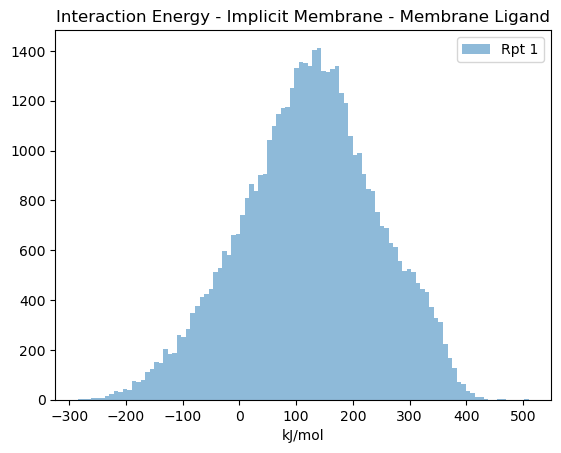

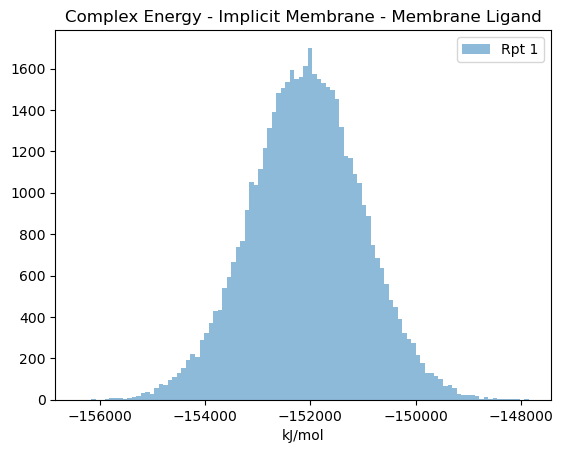

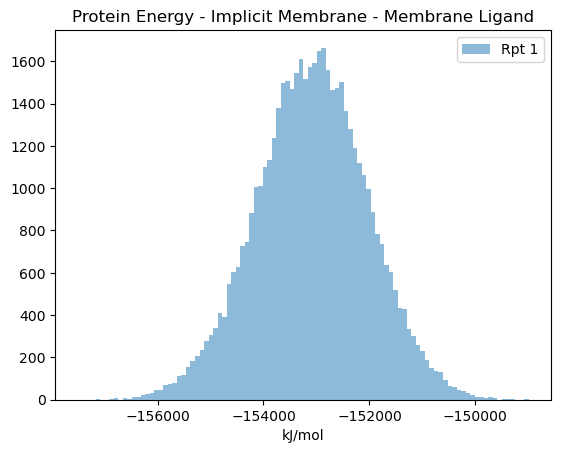

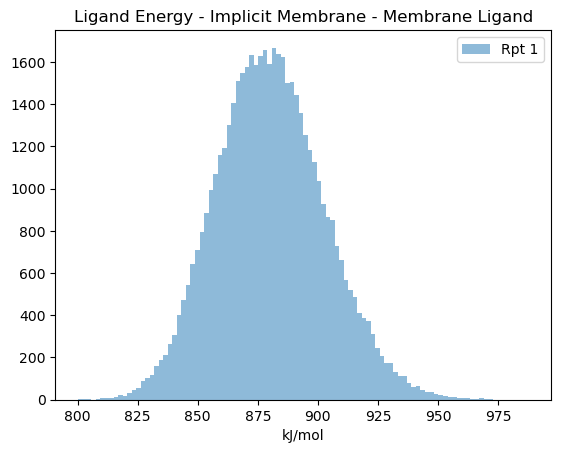

In [7]:
#Show results from testing one traj
import matplotlib.pyplot as plt
solvent_model = 'Implicit Membrane - Membrane Ligand'

plt.clf()
_ = plt.hist(energies[i-1, 0] - energies[i-1, 1] - energies[i-1, 2], bins=100, label=f'Rpt {i}', alpha=0.5)
plt.legend()
title=f'Interaction Energy - {solvent_model}'
plt.title(title)
plt.savefig('interaction_energy_figures/'+title.replace(' ','_'), dpi=900)
plt.xlabel('kJ/mol')
plt.show()

#Show results from testing one traj
plt.clf()
_ = plt.hist(energies[i-1, 0], bins=100, label=f'Rpt {i}', alpha=0.5)
plt.legend()
title=f'Complex Energy - {solvent_model}'
plt.title(title)
plt.savefig('interaction_energy_figures/'+title.replace(' ','_'), dpi=900)
plt.xlabel('kJ/mol')
plt.show()

#Show results from testing one traj
plt.clf()
_ = plt.hist(energies[i-1, 1], bins=100, label=f'Rpt {i}', alpha=0.5)
plt.legend()
title=f'Protein Energy - {solvent_model}'
plt.title(title)
plt.savefig('interaction_energy_figures/'+title.replace(' ','_'), dpi=900)
plt.xlabel('kJ/mol')
plt.show()

#Show results from testing one traj
plt.clf()
_ = plt.hist(energies[i-1, 2], bins=100, label=f'Rpt {i}', alpha=0.5)
plt.legend()
title=f'Ligand Energy - {solvent_model}'
plt.title(title)
plt.savefig('interaction_energy_figures/'+title.replace(' ','_'), dpi=900)
plt.xlabel('kJ/mol')
plt.show()

#### Block for run all

In [3]:
da_file_set = {}
names = ['7xk7_Korormicin', 'Aurachin_D', 'HQNO', 'UQ4']
for name in names:
    da_file_set[name] = []
    for i in range(1, 4):
        da_file_set[name].append([])
        for state in ['PL', 'P', 'L']:
            pdb_fn = f'./analyze_{name}_{i}/{name}_rpt{i}_prot_cof_{state}.pdb'
            dcd_fn = f'./analyze_{name}_{i}/{name}_rpt{i}_prot_cof_{state}.dcd'

            if name == 'UQ4' and state == 'L':
                xml_fn = f'./analyze_{name}_1/{name}_rpt1_prot_cof_{state}_fresh_OBC2_mem.xml'
            else:
                xml_fn = f'./analyze_{name}_1/{name}_rpt1_prot_cof_{state}_fresh_OBC2.xml'
    
            if False in [os.path.isfile(pdb_fn), os.path.isfile(dcd_fn), os.path.isfile(xml_fn)]:
                raise Exception(pdb_fn, dcd_fn, xml_fn)

            da_file_set[name][-1].append([pdb_fn, dcd_fn, xml_fn])           

In [11]:
energies = {}
for name, sett in da_file_set.items():
    energies[name] = {}
    for i, group in enumerate(sett):
        energies[name][f"rpt_{i+1}"] = ['complex', 'protein', 'ligand']
        print(name)
        for j, fn in enumerate(group):
            print('Use files', fn, 'to calculate', name, f"rpt_{i+1}", ['complex', 'protein', 'ligand'][j])
            energies[name][f"rpt_{i+1}"][j] = energies_from_files(pdb_fn=fn[0], dcd_fn=fn[1], xml_fn=fn[2])

7xk7_Korormicin
Use files ['./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL.pdb', './analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL.dcd', './analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL_fresh_OBC2.xml'] to calculate 7xk7_Korormicin rpt_1 complex
2025-03-21 14:33:34.274625 // Loading Trajectory ...
2025-03-21 14:35:28.515711 // Constructing Simulation ...
2025-03-21 14:35:30.292815 // Calculating Energies ...
2025-03-21 14:40:16.438418 // Done!
Use files ['./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_P.pdb', './analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_P.dcd', './analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_P_fresh_OBC2.xml'] to calculate 7xk7_Korormicin rpt_1 protein
2025-03-21 14:40:16.815654 // Loading Trajectory ...
2025-03-21 14:42:11.052899 // Constructing Simulation ...
2025-03-21 14:42:12.721563 // Calculating Energies ...
2025-03-21 14:46:58.210890 // Done!
Use files ['./analyze_7xk7_Korormicin_1/7xk7_

In [14]:
for name, set1 in energies.items():
    print(name)
    for rpt_name, set2 in set1.items():
        print(rpt_name)
        for state, arr in zip(['complex', 'protein', 'ligand'], set2):
            print(state, arr.shape)

7xk7_Korormicin
rpt_1
complex (50000,)
protein (50000,)
ligand (50000,)
rpt_2
complex (50000,)
protein (50000,)
ligand (50000,)
rpt_3
complex (50000,)
protein (50000,)
ligand (50000,)
Aurachin_D
rpt_1
complex (54396,)
protein (54396,)
ligand (54396,)
rpt_2
complex (54572,)
protein (54572,)
ligand (54572,)
rpt_3
complex (54553,)
protein (54553,)
ligand (54553,)
HQNO
rpt_1
complex (53813,)
protein (53813,)
ligand (53813,)
rpt_2
complex (53842,)
protein (53842,)
ligand (53842,)
rpt_3
complex (53729,)
protein (53729,)
ligand (53729,)
UQ4
rpt_1
complex (53425,)
protein (53425,)
ligand (53425,)
rpt_2
complex (53423,)
protein (53423,)
ligand (53423,)
rpt_3
complex (53464,)
protein (53464,)
ligand (53464,)


In [16]:
eners = {}

for name, set1 in energies.items():
    print(name)
    eners[name] = {}
    for rpt_name, set2 in set1.items():
        print(rpt_name)
        eners[name][rpt_name] = {}
        for i, (state, arr) in enumerate(zip(['complex', 'protein', 'ligand'], set2)):
            print(state, arr.shape)
            eners[name][rpt_name][state] = np.array([val._value for val in energies[name][rpt_name][i]])

7xk7_Korormicin
rpt_1
complex (50000,)
protein (50000,)
ligand (50000,)
rpt_2
complex (50000,)
protein (50000,)
ligand (50000,)
rpt_3
complex (50000,)
protein (50000,)
ligand (50000,)
Aurachin_D
rpt_1
complex (54396,)
protein (54396,)
ligand (54396,)
rpt_2
complex (54572,)
protein (54572,)
ligand (54572,)
rpt_3
complex (54553,)
protein (54553,)
ligand (54553,)
HQNO
rpt_1
complex (53813,)
protein (53813,)
ligand (53813,)
rpt_2
complex (53842,)
protein (53842,)
ligand (53842,)
rpt_3
complex (53729,)
protein (53729,)
ligand (53729,)
UQ4
rpt_1
complex (53425,)
protein (53425,)
ligand (53425,)
rpt_2
complex (53423,)
protein (53423,)
ligand (53423,)
rpt_3
complex (53464,)
protein (53464,)
ligand (53464,)


In [20]:
import pickle

In [21]:
# Pickling the dictionary
with open("interaction_energy_figures/energies_quantities.pickle", "wb") as f:
    pickle.dump(energies, f)

with open("interaction_energy_figures/energies_values.pickle", "wb") as f:
    pickle.dump(eners, f)

# # Unpickling the dictionary
# with open("my_dict.pickle", "rb") as file:
#     loaded_dict = pickle.load(file)

# print(loaded_dict)

In [22]:
import matplotlib.pyplot as plt

7xk7_Korormicin


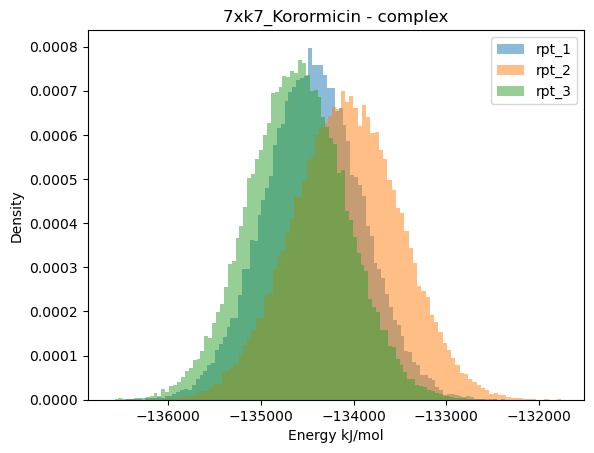

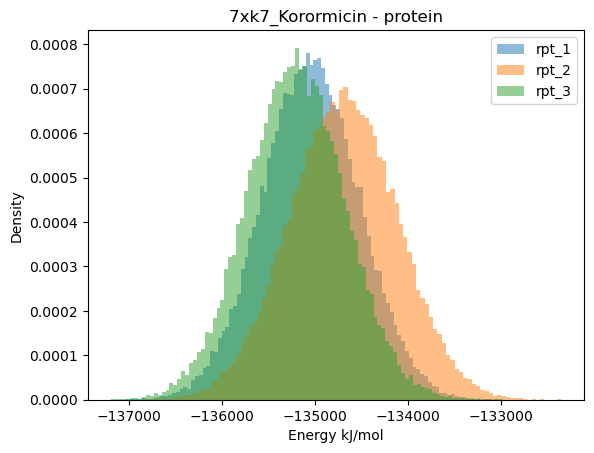

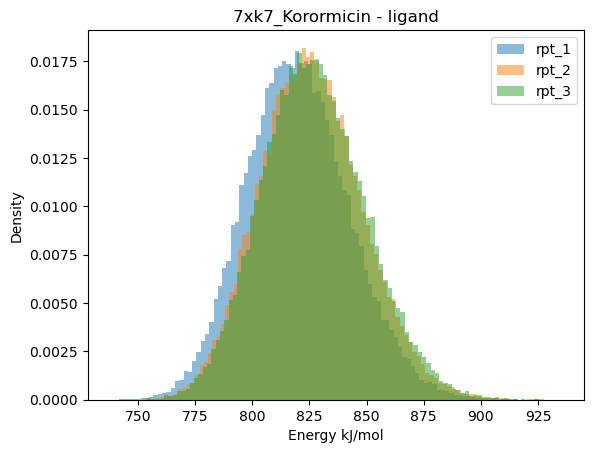

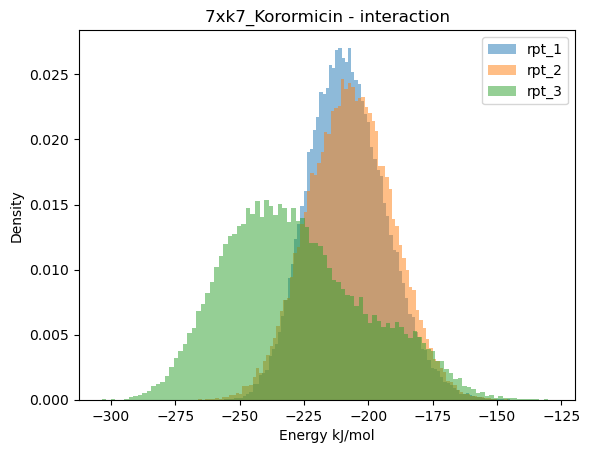

Aurachin_D


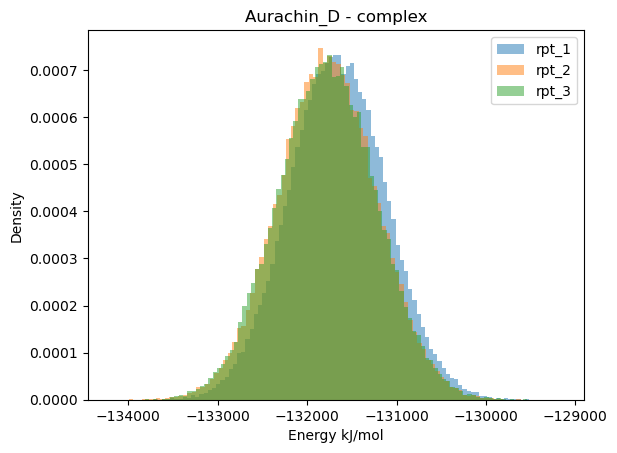

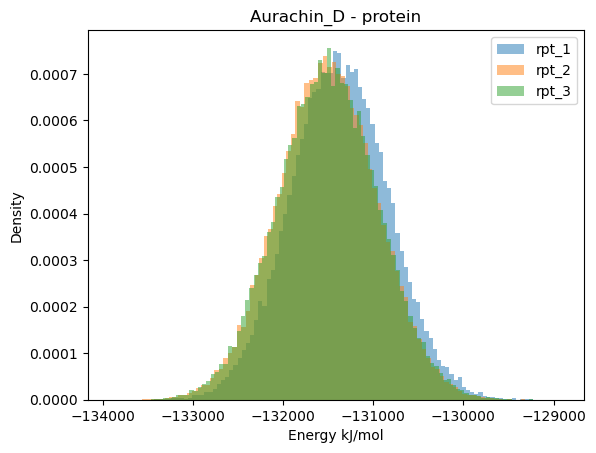

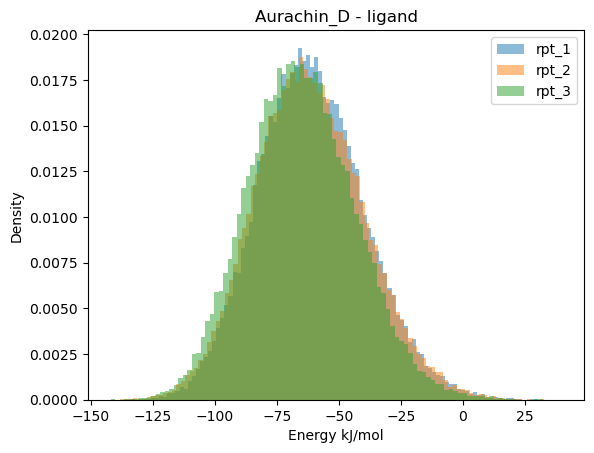

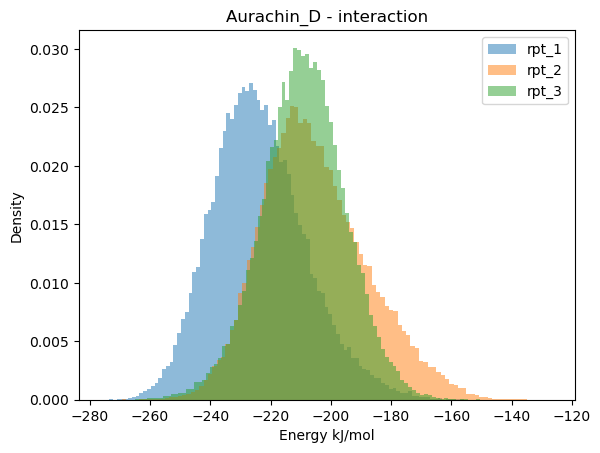

HQNO


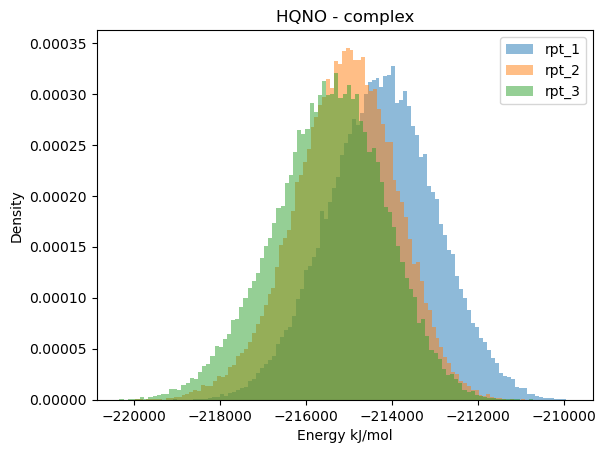

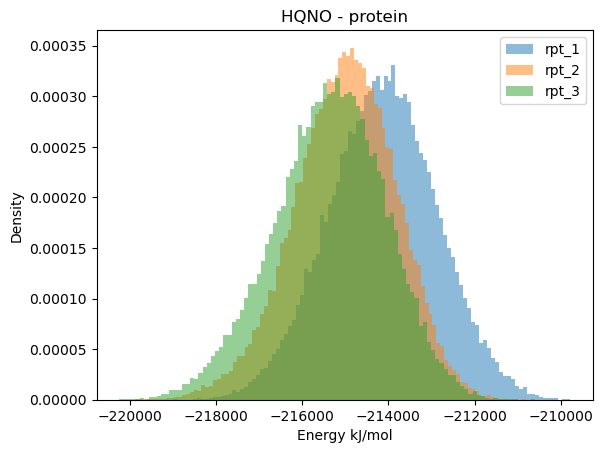

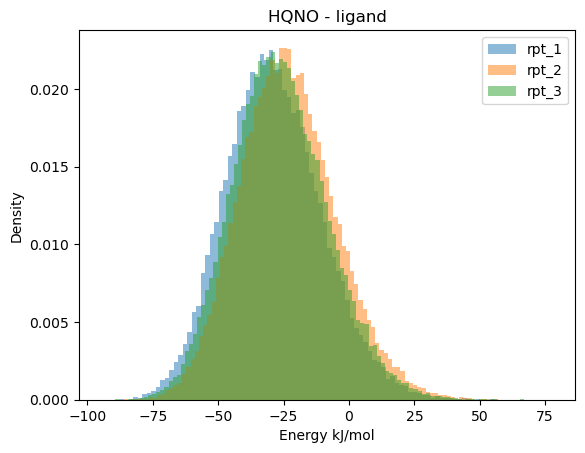

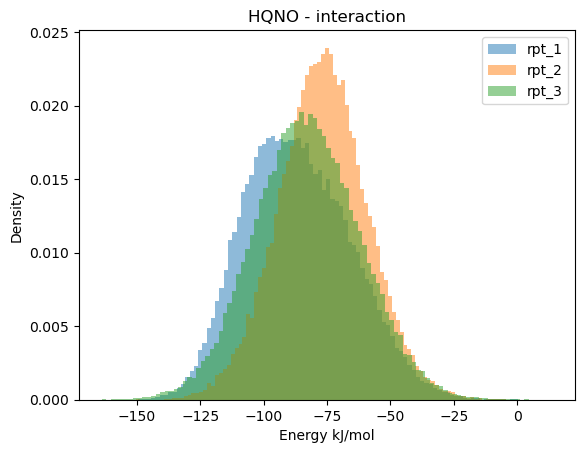

UQ4


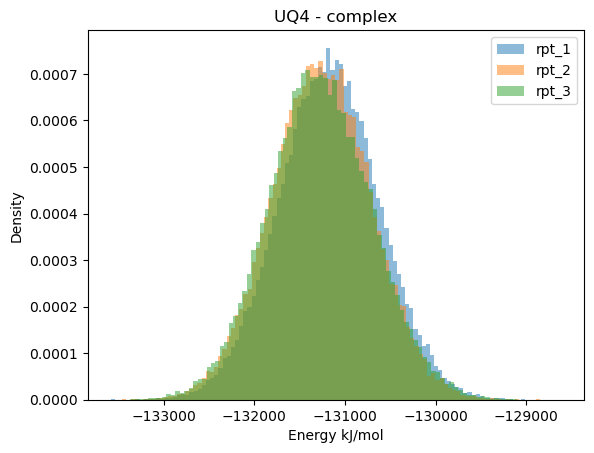

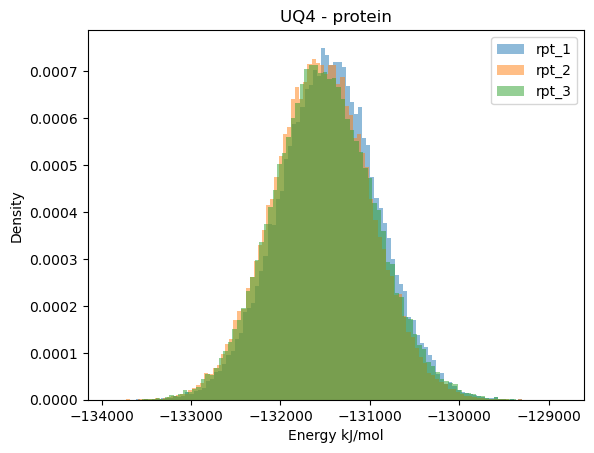

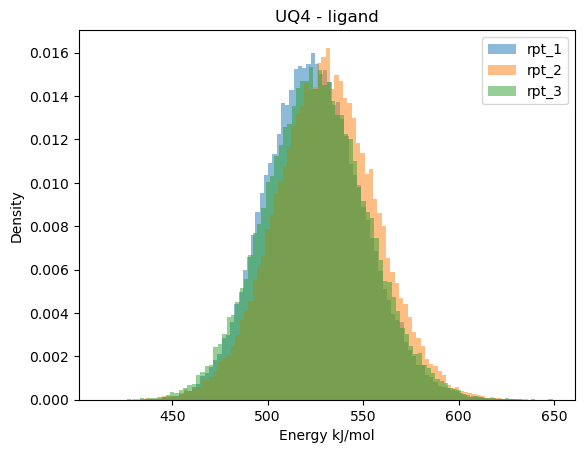

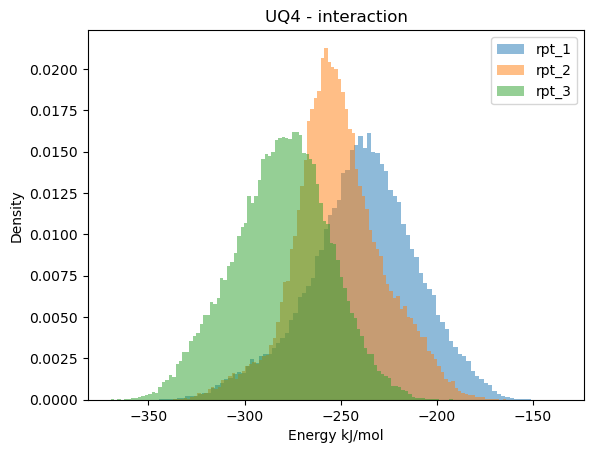

In [45]:
for name, rpt_set in eners.items():
    print(name)
    complex_eners = [eners[name][key]['complex'] for key in eners[name].keys()]
    protein_eners = [eners[name][key]['protein'] for key in eners[name].keys()]
    ligand_eners = [eners[name][key]['ligand'] for key in eners[name].keys()]
    interaction_eners = [complex_ener - protein_ener - ligand_ener for complex_ener, protein_ener, ligand_ener in zip(complex_eners, protein_eners, ligand_eners)]

    for state, ener_set in zip(['complex', 'protein', 'ligand', 'interaction'], [complex_eners, protein_eners, ligand_eners, interaction_eners]):
        plt.clf()
        for rpt_name, vals in zip(['rpt_1', 'rpt_2', 'rpt_3'], ener_set):
            _ = plt.hist(x=vals, bins=100, alpha=0.5, label=rpt_name, density=True)
        plt.title(f"{name} - {state}")
        plt.xlabel("Energy kJ/mol")
        plt.ylabel("Density")
        plt.legend()
        plt.show()

In [37]:
log_10_error = lambda val, err: 0.434*err/val
rt = 8.314*300/1000 #J/molK *K *1kJ/1000J

In [38]:
inter_means = {}
inter_stds = {}

for name, rpt_set in eners.items():
    print(name)
    complex_eners = [eners[name][key]['complex'] for key in eners[name].keys()]
    protein_eners = [eners[name][key]['protein'] for key in eners[name].keys()]
    ligand_eners = [eners[name][key]['ligand'] for key in eners[name].keys()]
    interaction_eners = [complex_ener - protein_ener - ligand_ener for complex_ener, protein_ener, ligand_ener in zip(complex_eners, protein_eners, ligand_eners)]

    inter_means[name] = [np.mean(_ener) for _ener in interaction_eners]
    inter_stds[name] = [np.std(_ener) for _ener in interaction_eners]

7xk7_Korormicin
Aurachin_D
HQNO
UQ4


In [39]:
inter_means

{'7xk7_Korormicin': [-208.18665473461192,
  -206.87711574937632,
  -228.02227662018416],
 'Aurachin_D': [-223.80939381584443, -205.32246687909984, -209.04622688584521],
 'HQNO': [-86.69223478378515, -76.64577529969739, -82.80404689072033],
 'UQ4': [-238.66922275087333, -251.14707615143442, -280.8374022391135]}

In [40]:
inter_stds

{'7xk7_Korormicin': [14.97393594589376,
  16.238712848136004,
  27.290681077552765],
 'Aurachin_D': [15.60074751171477, 17.437292751860284, 13.877080790690034],
 'HQNO': [20.88824619277109, 17.581588478795243, 20.86159291520245],
 'UQ4': [28.34651251431652, 23.457810456868724, 24.952297403355598]}

In [41]:
#Oscar Values for KD2
pKis = {'UQ4':(np.log10(0.16e-6), log_10_error(0.16e-6, 0.05e-6)),
        'HQNO':(np.log10(0.02e-6), log_10_error(0.02e-6, 0.008e-6)),
        'Aurachin_D':(np.log10(2.0e-9), log_10_error(2e-9, 0.3e-9)),
        '7xk7_Korormicin':(np.log10(5.0e-9), log_10_error(5e-9, 0.7e-9))}

colors = {'UQ4':'blue',
          'HQNO':'green',
          'Aurachin_D':'orange',
          '7xk7_Korormicin':'red'}

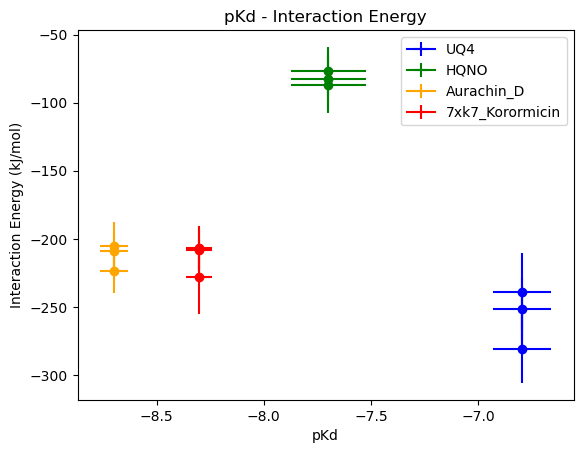

In [42]:
plt.clf()
for name in pKis.keys():
    xs = [pKis[name][0] for i in range(3)]
    xerrs = [pKis[name][1] for i in range(3)]
    ys = [inter_means[name][i] for i in range(3)]
    yerrs = [inter_stds[name][i] for i in range(3)]
    _ = plt.errorbar(x=xs, y=ys, xerr=xerrs, yerr=yerrs, color=colors[name], label=name)
    _ = plt.scatter(x=xs, y=ys, color=colors[name])
plt.legend()

plt.xlabel('pKd')
plt.ylabel('Interaction Energy (kJ/mol)')
plt.title('pKd - Interaction Energy')
plt.show()

In [3]:
names = ['7xk7_Korormicin', 'Aurachin_D', 'HQNO', 'UQ4']
state_sets = ['PL', 'P', 'L']
for name in names:
    for state in state_sets:
        for i in range(1, 4):
            pdb_fn = f'./analyze_{name}_{i}/{name}_rpt{i}_prot_cof_{state}.pdb'
            dcd_fn = f'./analyze_{name}_{i}/{name}_rpt{i}_prot_cof_{state}.dcd'
            xml_fn = f'./analyze_{name}_1/{name}_rpt1_prot_cof_{state}_fresh_OBC2.xml'

            if False in [os.path.isfile(pdb_fn), os.path.isfile(dcd_fn), os.path.isfile(xml_fn)]:
                raise Exception(pdb_fn, dcd_fn, xml_fn)
#If nothing is printed, good

In [4]:
dry_run = False
printf("START!")
for name in names:
    for state in state_sets:
        for i in range(1, 4):
            pdb_fn = f'./analyze_{name}_{i}/{name}_rpt{i}_prot_cof_{state}.pdb'
            print(pdb_fn)
            dcd_fn = f'./analyze_{name}_{i}/{name}_rpt{i}_prot_cof_{state}.dcd'
            print(dcd_fn)
            xml_fn = f'./analyze_{name}_1/{name}_rpt1_prot_cof_{state}_fresh_OBC2.xml'
            print(xml_fn)
            assert os.path.isfile(pdb_fn) and os.path.isfile(dcd_fn) and os.path.isfile(xml_fn)
            if not dry_run:
                energies = energies_from_files(pdb_fn=pdb_fn,
                                               dcd_fn=dcd_fn,
                                               xml_fn=xml_fn)
                energies = np.array([val._value for val in energies])
                np.save(f'./analyze_{name}_{i}/{name}_rpt{i}_energies_{state}_OBC2.npy', energies)
printf("DONE!")

2025-02-11 09:17:59.622995 // START!
./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL.pdb
./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL.dcd
./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL_fresh_OBC2.xml
2025-02-11 09:17:59.623654 // Loading Trajectory ...
2025-02-11 09:18:54.593957 // Constructing Simulation ...
2025-02-11 09:18:56.008908 // Calculating Energies ...
2025-02-11 09:23:42.460718 // Done!
./analyze_7xk7_Korormicin_2/7xk7_Korormicin_rpt2_prot_cof_PL.pdb
./analyze_7xk7_Korormicin_2/7xk7_Korormicin_rpt2_prot_cof_PL.dcd
./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL_fresh_OBC2.xml
2025-02-11 09:23:43.405193 // Loading Trajectory ...
2025-02-11 09:25:36.930353 // Constructing Simulation ...
2025-02-11 09:25:38.252947 // Calculating Energies ...
2025-02-11 09:30:24.747961 // Done!
./analyze_7xk7_Korormicin_3/7xk7_Korormicin_rpt3_prot_cof_PL.pdb
./analyze_7xk7_Korormicin_3/7xk7_Korormicin_rpt3_prot_cof_PL.dcd
./analyze_7xk7_Ko

7xk7_Korormicin 1 (50000,) (50000,) (50000,)
7xk7_Korormicin 2 (50000,) (50000,) (50000,)
7xk7_Korormicin 3 (50000,) (50000,) (50000,)


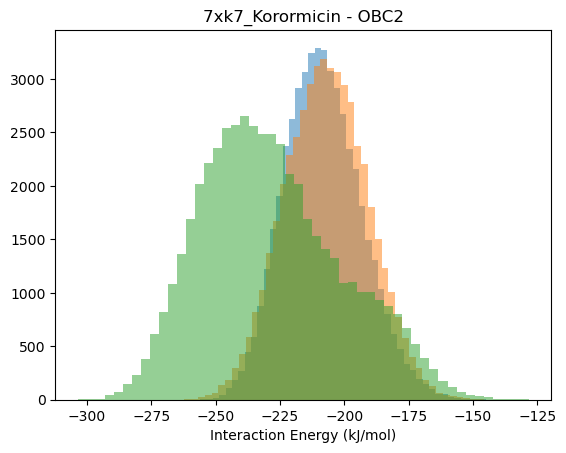

Aurachin_D 1 (54396,) (54396,) (54396,)
Aurachin_D 2 (54572,) (54572,) (54572,)
Aurachin_D 3 (54553,) (54553,) (54553,)


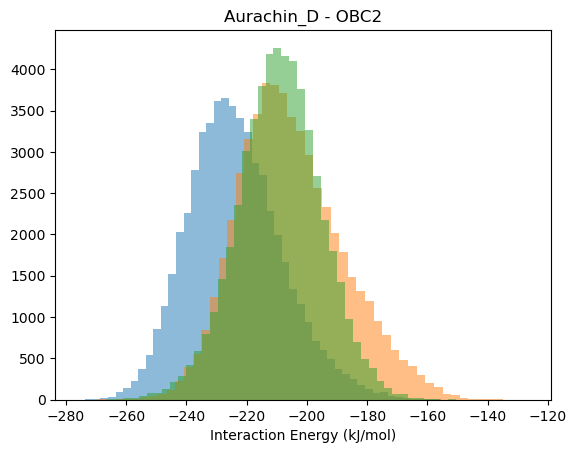

HQNO 1 (53813,) (53813,) (53813,)
HQNO 2 (53842,) (53842,) (53842,)
HQNO 3 (53729,) (53729,) (53729,)


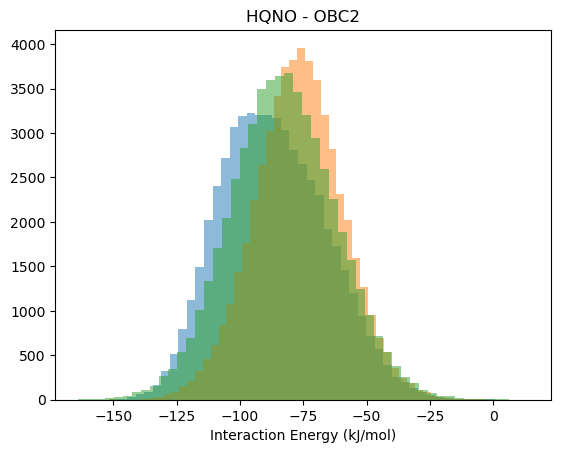

UQ4 1 (53425,) (53425,) (53425,)
UQ4 2 (53423,) (53423,) (53423,)
UQ4 3 (53464,) (53464,) (53464,)


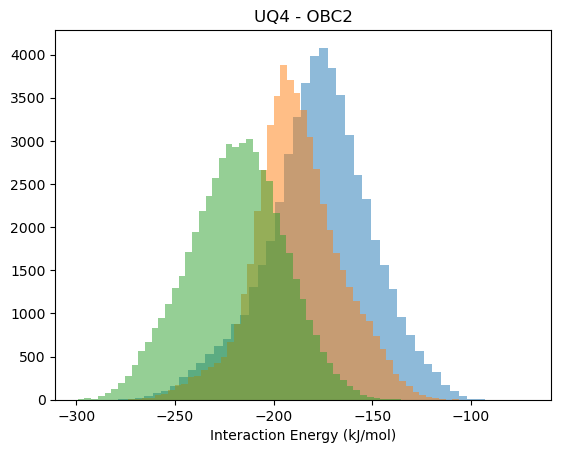

In [42]:
import matplotlib.pyplot as plt
interaction_energies = {}
for name in names:
    interaction_energies[name] = []
    for i in range(1, 4):
        ligand_energies = np.load(f'./analyze_{name}_{i}/{name}_rpt{i}_energies_L_OBC2.npy')
        protein_energies = np.load(f'./analyze_{name}_{i}/{name}_rpt{i}_energies_P_OBC2.npy')
        complex_energies = np.load(f'./analyze_{name}_{i}/{name}_rpt{i}_energies_PL_OBC2.npy')
        print(name, i, ligand_energies.shape, protein_energies.shape, complex_energies.shape)
        interaction_energies[name].append(complex_energies - protein_energies - ligand_energies)
    
    plt.clf()
    for i in range(1, 4):
        _ = plt.hist(interaction_energies[name][i-1], bins=50, alpha=0.5, label=f"rpt_{i}")
    plt.xlabel('Interaction Energy (kJ/mol)')
    plt.title(name + ' - OBC2')
    plt.savefig(f'figures/{name}_OBC2_interaction_energy.png', dpi=900)
    plt.show()

In [31]:
mean_std = {}

for name in names:
    print(name)
    means = [np.round(np.mean(interaction_energies[name][i]), decimals=3) for i in range(3)]
    stds = [np.round(np.std(interaction_energies[name][i]), decimals=3) for i in range(3)]
    mean_std[name] = (means, stds)
    for i in range(3):
        print(means[i], '+/-', stds[i])

7xk7_Korormicin
-208.187 +/- 14.974
-206.877 +/- 16.239
-228.022 +/- 27.291
Aurachin_D
-223.809 +/- 15.601
-205.322 +/- 17.437
-209.046 +/- 13.877
HQNO
-86.692 +/- 20.888
-76.646 +/- 17.582
-82.804 +/- 20.862
UQ4
-177.304 +/- 26.726
-188.328 +/- 22.136
-219.071 +/- 24.128


In [56]:
log_10_error = lambda val, err: 0.434*err/val
rt = 8.314*300/1000 #J/molK *K *1kJ/1000J
pIC50s = {'7xk7_Korormicin':(np.log10(5.0e-9), log_10_error(5e-9, 0.7e-9)),
          'Aurachin_D':(np.log10(2.0e-9), log_10_error(2e-9, 0.3e-9)),
          'HQNO':(np.log10(2000e-9), log_10_error(2000e-9, 250e-9))}
pKis = {'UQ4':(np.log10(0.15e-6), log_10_error(0.15e-6, 0.04e-6)),
        'HQNO':(np.log10(0.45e-6), log_10_error(0.45e-6, 0.1e-6)),
        '7xk7_Korormicin':(np.log10(0.082e-9), log_10_error(0.082e-9, 0))}
colors = {'UQ4':'blue',
          'HQNO':'green',
          'Aurachin_D':'orange',
          '7xk7_Korormicin':'red'}

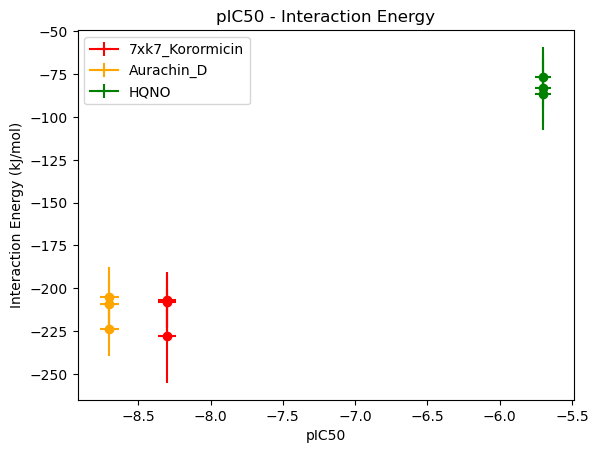

In [62]:
plt.clf()
for name in pIC50s.keys():
    xs = [pIC50s[name][0] for i in range(3)]
    xerrs = [pIC50s[name][1] for i in range(3)]
    ys = [mean_std[name][0][i] for i in range(3)]
    yerrs = [mean_std[name][1][i] for i in range(3)]
    _ = plt.errorbar(x=xs, y=ys, xerr=xerrs, yerr=yerrs, color=colors[name], label=name)
    _ = plt.scatter(x=xs, y=ys, color=colors[name])
plt.legend()

plt.xlabel('pIC50')
plt.ylabel('Interaction Energy (kJ/mol)')
plt.title('pIC50 - Interaction Energy')
plt.show()

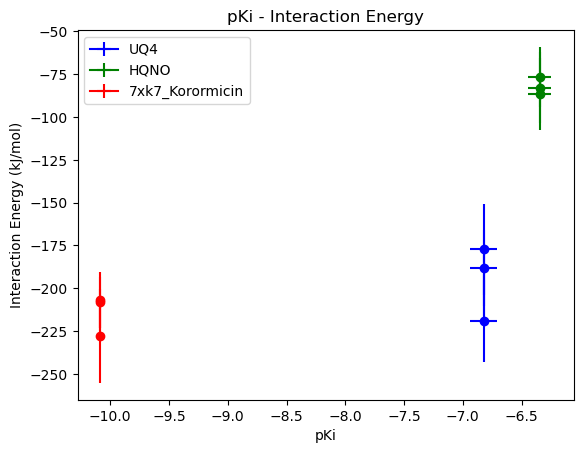

In [63]:
plt.clf()
for name in pKis.keys():
    xs = [pKis[name][0] for i in range(3)]
    xerrs = [pKis[name][1] for i in range(3)]
    ys = [mean_std[name][0][i] for i in range(3)]
    yerrs = [mean_std[name][1][i] for i in range(3)]
    _ = plt.errorbar(x=xs, y=ys, xerr=xerrs, yerr=yerrs, color=colors[name], label=name)
    _ = plt.scatter(x=xs, y=ys, color=colors[name])
plt.legend()

plt.xlabel('pKi')
plt.ylabel('Interaction Energy (kJ/mol)')
plt.title('pKi - Interaction Energy')
plt.show()

In [7]:
psi_func = lambda m: 2/(m-1)
m_func = lambda psi: (2/psi) + 1

In [22]:
psi_vals = np.logspace(-1, 1, 21)

In [23]:
m_vals = [round(val, 2) for val in m_func(psi_vals)]

In [24]:
print(sorted(m_vals, reverse=True))

[21.0, 16.89, 13.62, 11.02, 8.96, 7.32, 6.02, 4.99, 4.17, 3.52, 3.0, 2.59, 2.26, 2.0, 1.8, 1.63, 1.5, 1.4, 1.32, 1.25, 1.2]


In [4]:
#KORORMICIN
for i in range(1, 4):
    print(i)
    ligand_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.pdb',
                                          dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_L.dcd',
                                          xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L_fresh_OBC2.xml')
    if i == 1:
        energies = np.zeros((3, 3, len(ligand_energies)))
    
    protein_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.pdb',
                                           dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_P.dcd',
                                           xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_P_fresh_OBC2.xml',
                                           solvent='im_mem')
    
    complex_energies = energies_from_files(pdb_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.pdb',
                                           dcd_fn=f'./analyze_7xk7_Korormicin_{i}/7xk7_Korormicin_rpt{i}_prot_cof_PL.dcd',
                                           xml_fn='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_PL_fresh_OBC2.xml',
                                           solvent='im_mem')
    
    ligand_energies = np.array([val._value for val in ligand_energies])
    protein_energies = np.array([val._value for val in protein_energies])
    complex_energies = np.array([val._value for val in complex_energies])
    
    energies[i-1, 0, :] = complex_energies
    energies[i-1, 1, :] = protein_energies
    energies[i-1, 2, :] = ligand_energies

1
2025-02-10 22:19:36.890837 // Loading Trajectory ...
2025-02-10 22:19:37.412770 // Constructing Simulation ...
2025-02-10 22:19:37.561952 // Calculating Energies ...
2025-02-10 22:19:40.796579 // Done!
2025-02-10 22:19:40.867448 // Loading Trajectory ...
2025-02-10 22:22:24.512732 // Constructing Simulation ...
2025-02-10 22:22:26.218056 // Implicit Membrane Block
2025-02-10 22:22:26.545096 // Aligning to OPM reference ...
2025-02-10 22:22:52.722530 // Building Custom Force ...
2025-02-10 22:22:52.749239 // End Implicit Membrane Block
2025-02-10 22:22:52.870589 // Calculating Energies ...
2025-02-10 22:28:04.501262 // Done!
2025-02-10 22:28:04.546401 // Loading Trajectory ...
2025-02-10 22:30:45.854909 // Constructing Simulation ...
2025-02-10 22:30:47.515449 // Implicit Membrane Block
2025-02-10 22:30:48.143089 // Aligning to OPM reference ...
2025-02-10 22:31:13.749965 // Building Custom Force ...
2025-02-10 22:31:13.767966 // End Implicit Membrane Block
2025-02-10 22:31:13.902505 

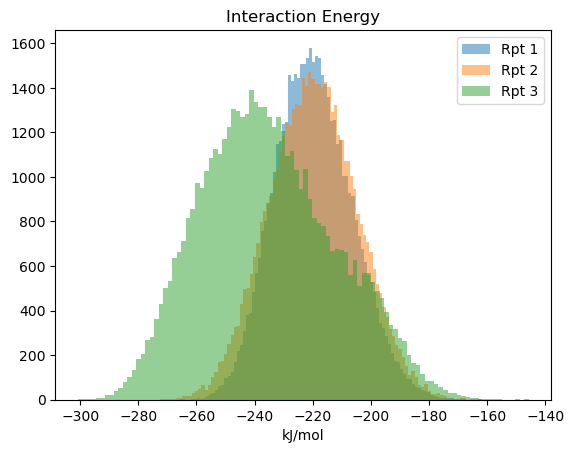

In [48]:
import matplotlib.pyplot as plt
n = 2 #For tests
#n = 4 #For all rpts

plt.clf()
for i in range(1, n):
    _ = plt.hist(energies[i-1, 0] - energies[i-1, 1] - energies[i-1, 2], bins=100, label=f'Rpt {i}', alpha=0.5)
plt.legend()
plt.title('Interaction Energy')
plt.xlabel('kJ/mol')
plt.show()

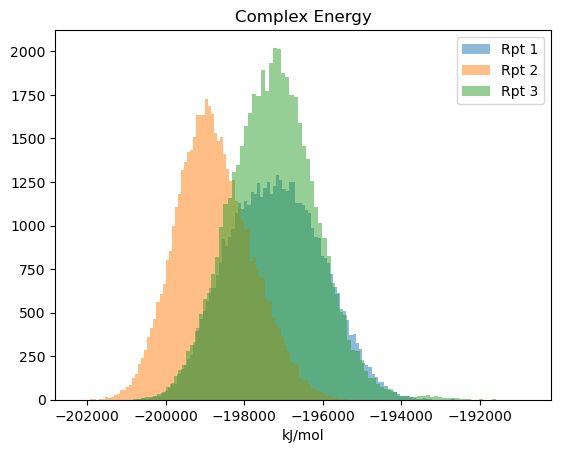

In [49]:
plt.clf()
for i in range(1, n):
    _ = plt.hist(energies[i-1, 0], bins=100, label=f'Rpt {i}', alpha=0.5)
plt.legend()
plt.title('Complex Energy')
plt.xlabel('kJ/mol')
plt.show()

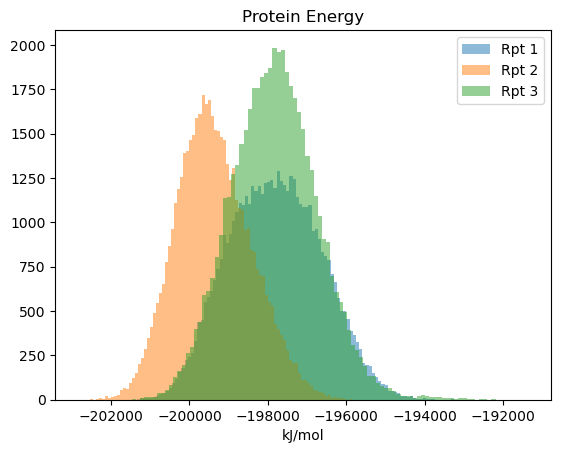

In [50]:
plt.clf()
for i in range(1, n):
    _ = plt.hist(energies[i-1, 1], bins=100, label=f'Rpt {i}', alpha=0.5)
plt.legend()
plt.title('Protein Energy')
plt.xlabel('kJ/mol')
plt.show()

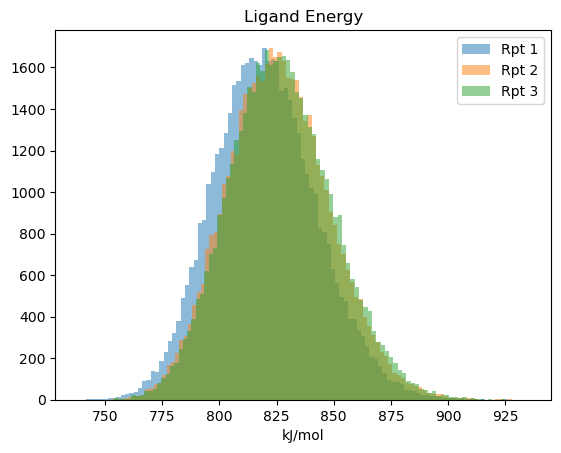

In [51]:
plt.clf()
for i in range(1, n):
    _ = plt.hist(energies[i-1, 2], bins=100, label=f'Rpt {i}', alpha=0.5)
plt.legend()
plt.title('Ligand Energy')
plt.xlabel('kJ/mol')
plt.show()

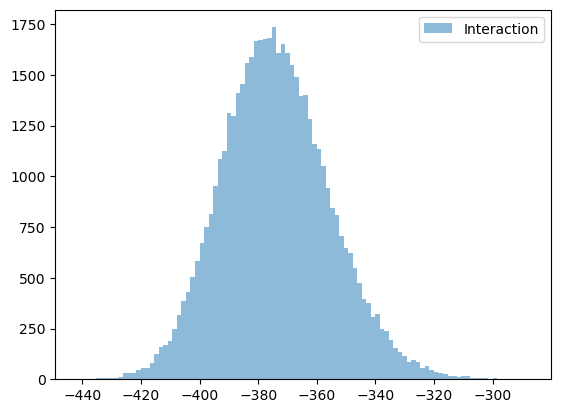

In [21]:
import matplotlib.pyplot as plt

plt.clf()
_ = plt.hist(complex_energies - protein_energies - ligand_energies, bins=100, label='Interaction', alpha=0.5)
plt.legend()
plt.show()

In [10]:
lig_traj = md.load('./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L.dcd',
                   top='./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L.pdb')

In [12]:
pdb = PDBFile('./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L.pdb')

In [13]:
with open('./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_L.xml', 'r') as f:
    system = XmlSerializer.deserialize(f.read())

In [14]:
integrator = LangevinIntegrator(300*kelvin, 1/picosecond, 2*femtosecond)

In [15]:
platform = Platform.getPlatformByName('OpenCL')
properties = {'OpenCLPrecision': 'mixed'}

In [16]:
sim = Simulation(pdb.topology, system, integrator, platform, properties)

In [20]:
system.getForces()

[<openmm.openmm.HarmonicBondForce; proxy of <Swig Object of type 'OpenMM::HarmonicBondForce *' at 0x7f8130213c90> >,
 <openmm.openmm.HarmonicAngleForce; proxy of <Swig Object of type 'OpenMM::HarmonicAngleForce *' at 0x7f8130213db0> >,
 <openmm.openmm.PeriodicTorsionForce; proxy of <Swig Object of type 'OpenMM::PeriodicTorsionForce *' at 0x7f81302136c0> >,
 <openmm.openmm.NonbondedForce; proxy of <Swig Object of type 'OpenMM::NonbondedForce *' at 0x7f8130213390> >]

In [17]:
for i in range(lig_traj.n_frames):
    sim.context.setPositions(lig_traj.xyz[i])
    print(sim.context.getState(getEnergy=True).getPotentialEnergy())

14182008.25187831 kJ/mol
14201475.394828716 kJ/mol
14103970.656869704 kJ/mol
14189910.832552014 kJ/mol
14197063.550995938 kJ/mol
14147072.791746652 kJ/mol
14162500.383922556 kJ/mol
14269206.208379228 kJ/mol
14278452.95354212 kJ/mol
14177690.087954542 kJ/mol
14217545.973473094 kJ/mol
14219580.013530655 kJ/mol
14164740.42430512 kJ/mol
14079323.818785772 kJ/mol
14012280.48625659 kJ/mol
14042683.474922687 kJ/mol
14119932.998776734 kJ/mol
14043033.223757401 kJ/mol
14158969.104839092 kJ/mol
14273980.742403382 kJ/mol
14108044.264721243 kJ/mol
14216681.186192317 kJ/mol
14066433.243931498 kJ/mol
14148092.456174789 kJ/mol
14046571.030797217 kJ/mol
14250755.592239227 kJ/mol
14127948.467354432 kJ/mol
14217770.80922632 kJ/mol
14321944.138706254 kJ/mol
14091512.697313478 kJ/mol
14140288.974863151 kJ/mol
14162659.90315811 kJ/mol
14218126.08668704 kJ/mol
14182860.632133307 kJ/mol
14196889.578969719 kJ/mol
14211595.033709673 kJ/mol
14296374.39632524 kJ/mol
14168187.701869974 kJ/mol
14119325.57536241 kJ

In [14]:
test1 = md.load('../simulate/7xk7_Korormicin_sim/7xk7_Korormicin_system.pdb')

In [15]:
test2 = md.load('./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_chainAB.pdb')

In [16]:
test3 = md.load('./analyze_7xk7_Korormicin_1/7xk7_Korormicin_rpt1_prot_cof_ion.pdb')

In [44]:
sel1 = 'not resname HOH and not resname POP and not resname PVC and not resname SOD and not resname CLA'
sel2 = 'not resname SOD and not resname CLA'

In [45]:
test1.xyz[:, test1.top.select(sel1), :].shape == test3.xyz[:, test3.top.select(sel2), :].shape

True

In [46]:
sel1 = 'not resname HOH and not resname POP and not resname PVC and not resname SOD and not resname CLA and not resname UNK'
sel2 = 'not resname SOD and not resname CLA and not resname UNK'

In [47]:
test1.xyz[:, test1.top.select(sel1)].shape == test3.xyz[:, test3.top.select(sel2)].shape

True

In [48]:
sel = 'resname UNK'

In [49]:
test1.xyz[:, test1.top.select(sel)].shape == test3.xyz[:, test3.top.select(sel)].shape

True

In [23]:
chainid = 0
indices = test1.top.select(f"chainid {chainid}")

while indices.size > 0:
    residue_names = []
    for atom in test1.top.atoms:
        if atom.index in indices and atom.residue.name not in residue_names:
            residue_names.append(atom.residue.name)
    print(chainid, sorted(residue_names))
    
    chainid += 1
    indices = test1.top.select(f"chainid {chainid}")

0 ['HOH', 'POP', 'PVC']
1 ['CLA', 'SOD']
2 ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL']
3 ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THO', 'THR', 'TRP', 'TYR', 'VAL']
4 ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THO', 'THR', 'TRP', 'TYR', 'VAL']
5 ['ALA', 'ARG', 'ASN', 'ASP', 'CYF', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL']
6 ['ALA', 'ARG', 'ASN', 'ASP', 'CYF', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL']
7 ['ALA', 'ARG', 'ASN', 'ASP', 'CYF', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL']
8 ['FES']
9 ['FAD', 'FES']
10 ['FMN']
11 ['FMN', 'RBF']
12 ['UNK']
